## Breast Cancer Detection Using Machine Learning
**Introduction**

Breast cancer is one of the most common and life-threatening diseases affecting women worldwide. Early and accurate detection plays a critical role in improving survival rates and treatment outcomes. Traditional diagnosis methods rely on manual examination by medical professionals, which can be time-consuming and prone to human error. Machine learning offers a powerful alternative by automating the classification of tumors based on measurable cell characteristics, enabling faster and more consistent predictions.





**Objective**

The goal of this project is to build a machine learning classification model that can accurately predict whether a breast tumor is malignant (cancerous) or benign (non-cancerous) based on features extracted from digitized images of fine needle aspirate (FNA) of breast masses. These features describe characteristics of the cell nuclei such as radius, texture, perimeter, area, smoothness, and concavity.


**Dataset**

The Breast Cancer Wisconsin (Diagnostic) Dataset contains 569 samples with 30 numeric features describing cell nucleus characteristics, along with a binary target variable — M (Malignant) or B (Benign). The dataset was sourced from the UCI Machine Learning Repository and is widely used as a benchmark for binary classification problems in the healthcare domain.


**Tools and Technologies Used**

Language: Python
Libraries: Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Imbalanced-learn
Models: Logistic Regression, Decision Tree, Random Forest, Support Vector Machine
Techniques: EDA, Feature Scaling, SMOTE, Label Encoding, Cross-validation



In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE


In [25]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [3]:
import os
os.makedirs("plots", exist_ok=True)


## Step 1: Data Collection and Initial Exploration

In this step we import the dataset and inspect its basic properties — shape, data types, null values, duplicate rows, and column names — to understand what we are working with before any processing begins.

In [4]:
df = pd.read_csv("breast_cancer_data.csv")


In [5]:
print("\n--- Shape of dataset ---")
print(df.shape)

print("\n--- First 5 rows ---")
print(df.head())

print("\n--- Info ---")
print(df.info())

print("\n--- Describe (statistical summary) ---")
print(df.describe())

print("\n--- Column names ---")
print(list(df.columns))




--- Shape of dataset ---
(569, 33)

--- First 5 rows ---
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   .

In [6]:
print("\n--- Null values per column ---")
print(df.isnull().sum())

print("\n--- Total null values in dataset ---")
print(df.isnull().sum().sum())




--- Null values per column ---
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal

In [7]:
print("\n--- Duplicate rows ---")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print("\n--- Duplicate columns ---")
duplicate_cols = df.columns[df.columns.duplicated()]
print(f"Duplicate columns: {list(duplicate_cols) if len(duplicate_cols) > 0 else 'None'}")



--- Duplicate rows ---
Number of duplicate rows: 0

--- Duplicate columns ---
Duplicate columns: None


## Step 2: Data Preprocessing

In this step we clean the data by dropping unwanted columns (id and Unnamed: 32), handle the class imbalance using SMOTE, and encode the categorical target variable (M/B) into numeric format (0/1) so it can be used by machine learning models.

In [8]:
# ════════════════════════════════════════════════════════════════
# 2. DATA PREPROCESSING
# ════════════════════════════════════════════════════════════════
# Drop unwanted columns
cols_to_drop = []
if 'id' in df.columns:
    cols_to_drop.append('id')
if 'Unnamed: 32' in df.columns:
    print(f"'Unnamed: 32' is empty in {df['Unnamed: 32'].isna().sum()} of {len(df)} rows — dropping it.")
    cols_to_drop.append('Unnamed: 32')


'Unnamed: 32' is empty in 569 of 569 rows — dropping it.


In [9]:
df = df.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")
print(f"Shape after dropping: {df.shape}")


Dropped columns: ['id', 'Unnamed: 32']
Shape after dropping: (569, 31)


In [10]:
# Handling Imbalanced Data
print(df['diagnosis'].value_counts())
print(f"\nBenign (B):    {df['diagnosis'].value_counts()['B']} "
      f"({df['diagnosis'].value_counts(normalize=True)['B']*100:.1f}%)")
print(f"Malignant (M): {df['diagnosis'].value_counts()['M']} "
      f"({df['diagnosis'].value_counts(normalize=True)['M']*100:.1f}%)")
print("\nNote: Dataset is moderately imbalanced (63% benign vs 37% malignant).")
print("We will apply SMOTE after the train/test split to balance the TRAINING")
print("set only, avoiding data leakage into test data.")


diagnosis
B    357
M    212
Name: count, dtype: int64

Benign (B):    357 (62.7%)
Malignant (M): 212 (37.3%)

Note: Dataset is moderately imbalanced (63% benign vs 37% malignant).
We will apply SMOTE after the train/test split to balance the TRAINING
set only, avoiding data leakage into test data.


In [11]:
# Encoding Categorical Features
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])
print(f"Encoding map: {dict(zip(le.classes_, le.transform(le.classes_)))}")



Encoding map: {'B': np.int64(0), 'M': np.int64(1)}


## Step 3: Exploratory Data Analysis (EDA)

In this step we explore the data distribution, examine the class balance between malignant and benign cases, and analyze correlations between features to understand which variables are most useful for prediction.

In [12]:
print("\n--- Data distribution summary ---")
print(df.describe().T[['mean', 'std', 'min', 'max']])

print("\n--- Malignant vs Benign case counts ---")
print(df['diagnosis'].value_counts())

print("\n--- Correlation with target (top 10 features) ---")
corr_with_target = df.drop(columns=['diagnosis']).corr()['diagnosis_encoded'].abs().sort_values(ascending=False)
print(corr_with_target.head(11))



--- Data distribution summary ---
                               mean         std         min         max
radius_mean               14.127292    3.524049    6.981000    28.11000
texture_mean              19.289649    4.301036    9.710000    39.28000
perimeter_mean            91.969033   24.298981   43.790000   188.50000
area_mean                654.889104  351.914129  143.500000  2501.00000
smoothness_mean            0.096360    0.014064    0.052630     0.16340
compactness_mean           0.104341    0.052813    0.019380     0.34540
concavity_mean             0.088799    0.079720    0.000000     0.42680
concave points_mean        0.048919    0.038803    0.000000     0.20120
symmetry_mean              0.181162    0.027414    0.106000     0.30400
fractal_dimension_mean     0.062798    0.007060    0.049960     0.09744
radius_se                  0.405172    0.277313    0.111500     2.87300
texture_se                 1.216853    0.551648    0.360200     4.88500
perimeter_se               2.

## Step 4: Visualization

In this step we create 7 different types of visualizations to understand the data better and identify patterns that separate malignant from benign tumors.

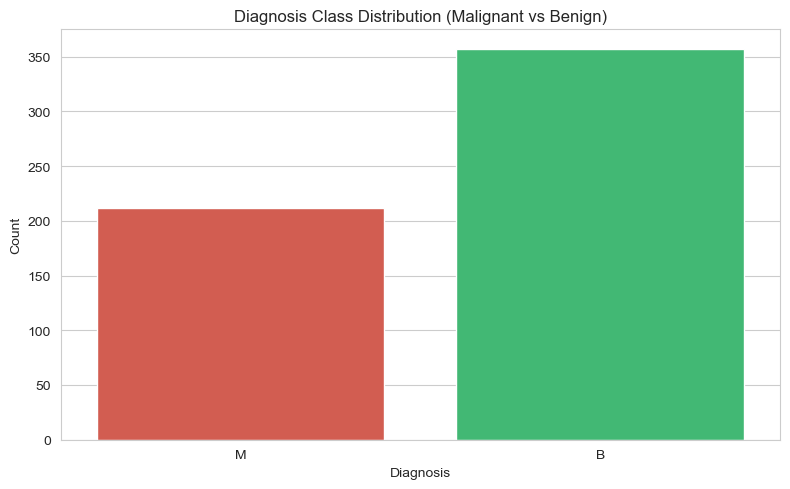

In [43]:
# Countplot
plt.figure()
sns.countplot(data=df, x='diagnosis', hue='diagnosis', palette=['#e74c3c', '#2ecc71'])
plt.title("Diagnosis Class Distribution (Malignant vs Benign)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("plots/01_countplot_diagnosis.png", dpi=120)
plt.show()

The dataset contains 357 benign and 212 malignant cases, showing a moderate class imbalance of 63% vs 37%. This imbalance was handled using SMOTE during model training to prevent bias towards the majority class.

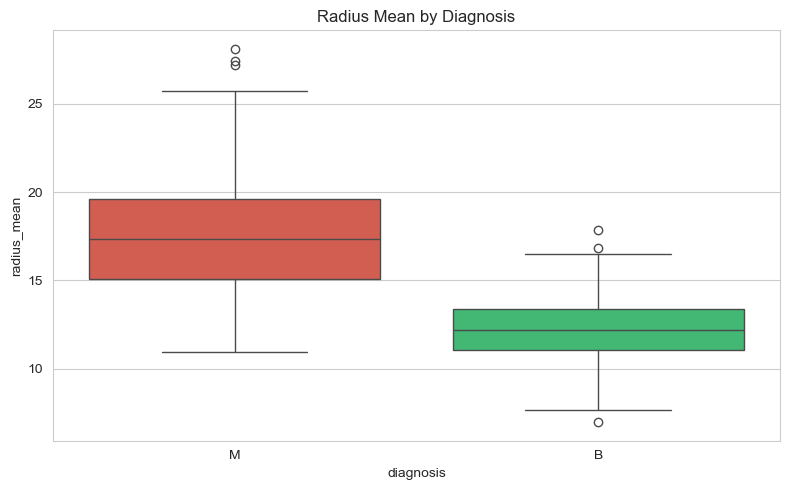

In [44]:
# Boxplot
plt.figure()
sns.boxplot(data=df, x='diagnosis', y='radius_mean', hue='diagnosis', palette=['#e74c3c', '#2ecc71'])
plt.title("Radius Mean by Diagnosis")
plt.tight_layout()
plt.savefig("plots/02_boxplot_radius_mean.png", dpi=120)
plt.show()

Malignant tumors show a clearly higher median radius mean compared to benign ones, with minimal overlap. This confirms that cell nucleus size is a strong indicator of malignancy and one of the most important features for classification.

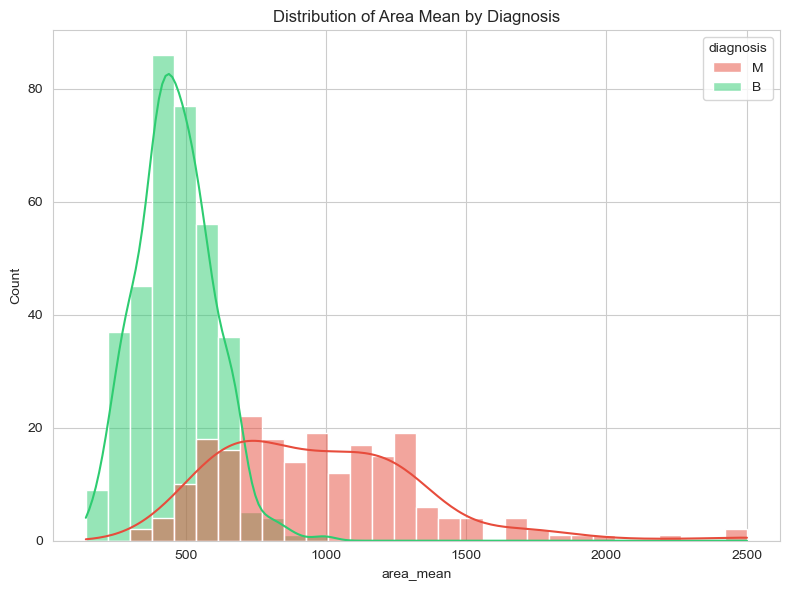

In [16]:
# Histplot
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='area_mean', hue='diagnosis', kde=True, bins=30,
             palette=['#e74c3c', '#2ecc71'])
plt.title("Distribution of Area Mean by Diagnosis")
plt.tight_layout()
plt.savefig("plots/03_histplot_area_mean.png", dpi=120)
plt.show()


Benign tumors have a lower and more concentrated area mean, while malignant tumors spread across higher values. The two classes show distinct distributions, confirming area mean as a useful predictor, though a small overlap explains why no model achieves 100% accuracy.


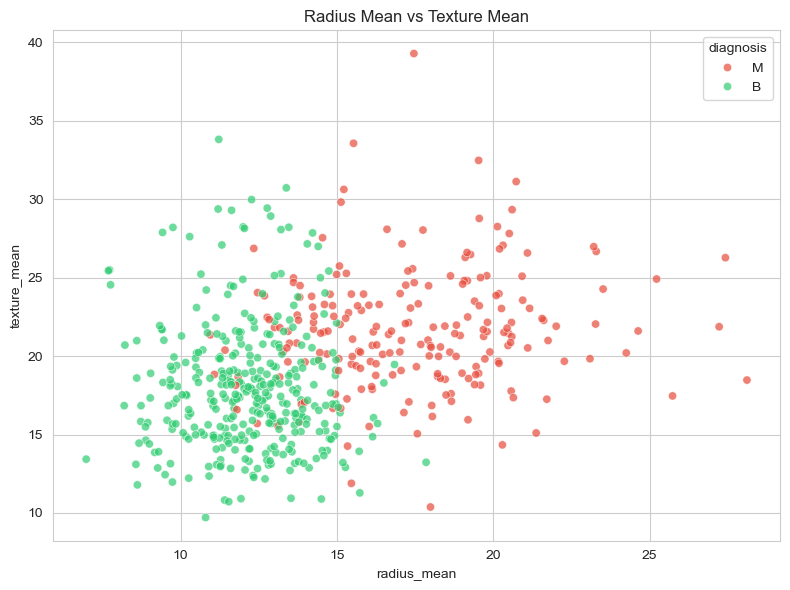

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='radius_mean', y='texture_mean', hue='diagnosis',
                palette=['#e74c3c', '#2ecc71'], alpha=0.7)
plt.title("Radius Mean vs Texture Mean")
plt.tight_layout()
plt.savefig("plots/04_scatterplot_radius_texture.png", dpi=120)
plt.show()



Malignant tumors cluster in the upper right area of the plot, indicating higher values for both features. While some overlap exists, the general separation between classes confirms that combining multiple features improves classification performance.


<Figure size 800x600 with 0 Axes>

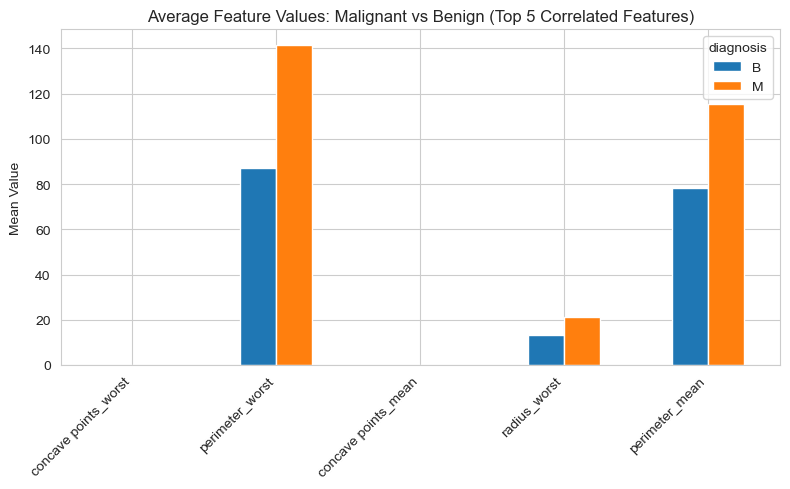

In [38]:
top_features = corr_with_target.index[1:6]
plt.figure(figsize=(8, 6))
df.groupby('diagnosis')[list(top_features)].mean().T.plot(kind='bar')
plt.title("Average Feature Values: Malignant vs Benign (Top 5 Correlated Features)")
plt.ylabel("Mean Value")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("plots/05_barplot_top_features.png", dpi=120)
plt.show()


Malignant tumors consistently show higher average values across all top 5 correlated features compared to benign ones. Features like worst concave points and worst perimeter show the largest differences, confirming their strong predictive power.


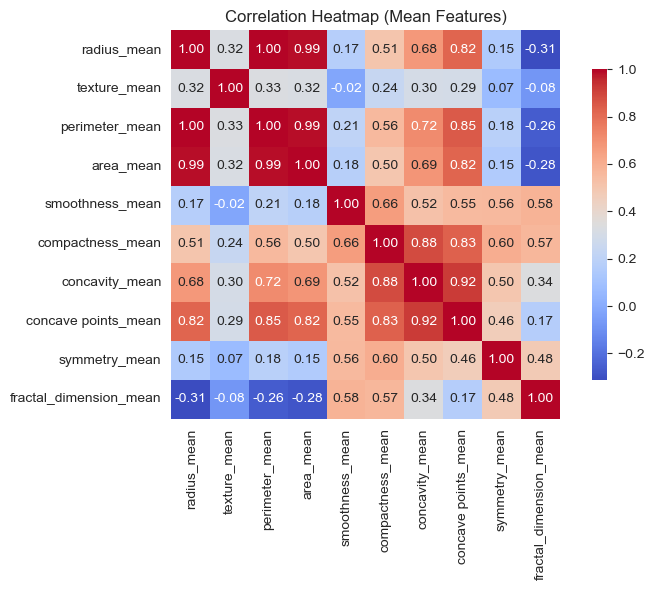

In [19]:
# Heatmap
mean_cols = [c for c in df.columns if c.endswith('_mean')]
plt.figure(figsize=(8, 6))
sns.heatmap(df[mean_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap (Mean Features)")
plt.tight_layout()
plt.savefig("plots/06_heatmap_correlation.png", dpi=120)
plt.show()


Strong correlations exist between radius, perimeter, and area features (above 0.99), which is expected since these measurements are geometrically related. Concave points and concavity features show the strongest correlation with the target variable.

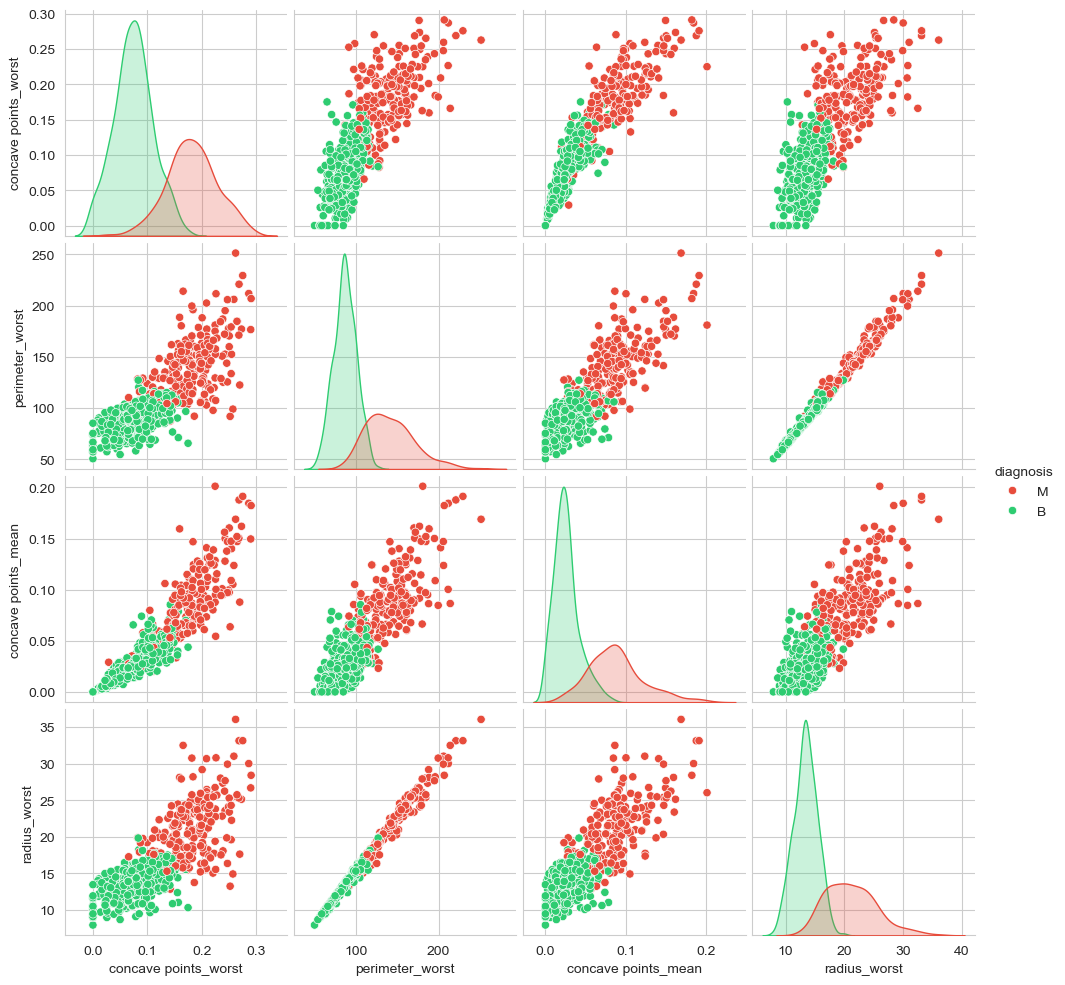

In [39]:
# Pairplot 
pairplot_features = list(corr_with_target.index[1:5]) + ['diagnosis'] 
sns.pairplot(df[pairplot_features], hue='diagnosis', palette=['#e74c3c', '#2ecc71']) 
plt.savefig("plots/07_pairplot_top_features.png", dpi=120) 
plt.show() 

Clear separation between malignant and benign classes is visible across most feature combinations, confirming that the top correlated features together provide strong signals for classification.


## Step 5: Feature Scaling

In this step we apply StandardScaler to normalize all features to the same scale. This is important because features like area_mean have much larger values than smoothness_mean, and models like SVM and Logistic Regression are sensitive to the scale of input features.

In [22]:
X = df.drop(columns=['diagnosis', 'diagnosis_encoded'])
y = df['diagnosis_encoded']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")


Feature matrix shape: (569, 30)
Target vector shape: (569,)


In [23]:
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X) 
X_scaled = pd.DataFrame(X_scaled, columns=X.columns) 
print("\n--- Before scaling (first feature, first 5 values) ---") 
print(X.iloc[:5, 0].values) 
print("\n--- After scaling (first feature, first 5 values) ---") 
print(X_scaled.iloc[:5, 0].values) 

  


--- Before scaling (first feature, first 5 values) ---
[17.99 20.57 19.69 11.42 20.29]

--- After scaling (first feature, first 5 values) ---
[ 1.09706398  1.82982061  1.57988811 -0.76890929  1.75029663]


## Step 6: Model Selection and Fitting

In this step we split the data into training (80%) and test (20%) sets, apply SMOTE to balance the training data, and train 4 different classification models — Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine — to compare their performance.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")

print("\n--- Applying SMOTE to balance training data ---")
print(f"Before SMOTE: {dict(pd.Series(y_train).value_counts())}")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print(f"After SMOTE:  {dict(pd.Series(y_train_balanced).value_counts())}")




Train set: 455 samples
Test set:  114 samples

--- Applying SMOTE to balance training data ---
Before SMOTE: {0: np.int64(285), 1: np.int64(170)}
After SMOTE:  {1: np.int64(285), 0: np.int64(285)}


In [28]:
models = {"Logistic Regression":     LogisticRegression(max_iter=5000, random_state=42),
        "Decision Tree":           DecisionTreeClassifier(random_state=42),
        "Random Forest":           RandomForestClassifier(n_estimators=100, random_state=42),
        "Support Vector Machine":  SVC(kernel='rbf', probability=True, random_state=42),}
results = {}
predictions = {}

In [29]:
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = {"accuracy": acc, "f1_score": f1}
    predictions[name] = y_pred
    print(f"\n{name}: Accuracy = {acc:.4f} | F1 Score = {f1:.4f}")



Logistic Regression: Accuracy = 0.9737 | F1 Score = 0.9639

Decision Tree: Accuracy = 0.9298 | F1 Score = 0.9024

Random Forest: Accuracy = 0.9737 | F1 Score = 0.9630

Support Vector Machine: Accuracy = 0.9825 | F1 Score = 0.9762


## Step 7: Model Evaluation

In this step we evaluate all 4 models using accuracy score, F1 score, classification report, and confusion matrix to identify the best performing model and understand where each model makes errors.

In [31]:
for name, model in models.items():
    y_pred = predictions[name]
    print(f"\n{'─'*60}")
    print(f"  {name}")
    print(f"{'─'*60}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['benign', 'malignant']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))



────────────────────────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

      benign       0.97      0.99      0.98        72
   malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
[[71  1]
 [ 2 40]]

────────────────────────────────────────────────────────────
  Decision Tree
────────────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

      benign       0.93      0.96      0.95        72
   malignant       0.93      0.88      0.90        42

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.9

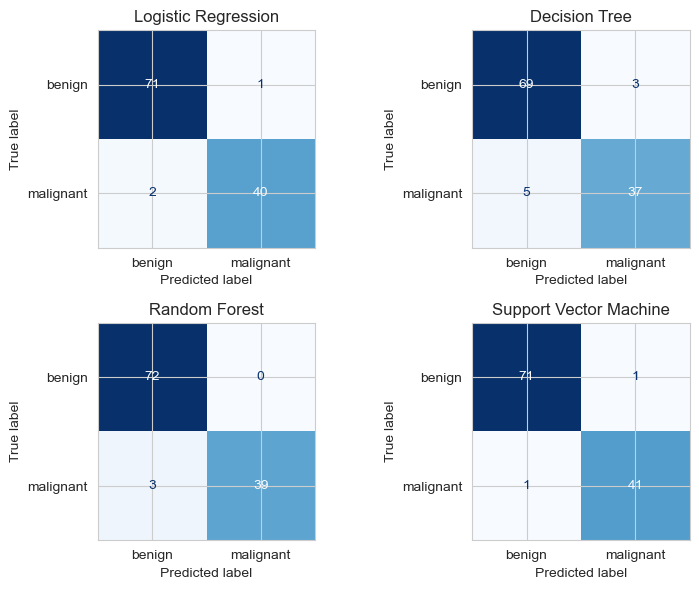


Saved: confusion matrices


In [33]:
# Confusion matrices plot
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
for ax, (name, model) in zip(axes.flatten(), models.items()):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'malignant'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("plots/08_confusion_matrices.png", dpi=120)
plt.show()
print("\nSaved: confusion matrices")


                        accuracy  f1_score
Support Vector Machine  0.982456  0.976190
Logistic Regression     0.973684  0.963855
Random Forest           0.973684  0.962963
Decision Tree           0.929825  0.902439


<Figure size 900x500 with 0 Axes>

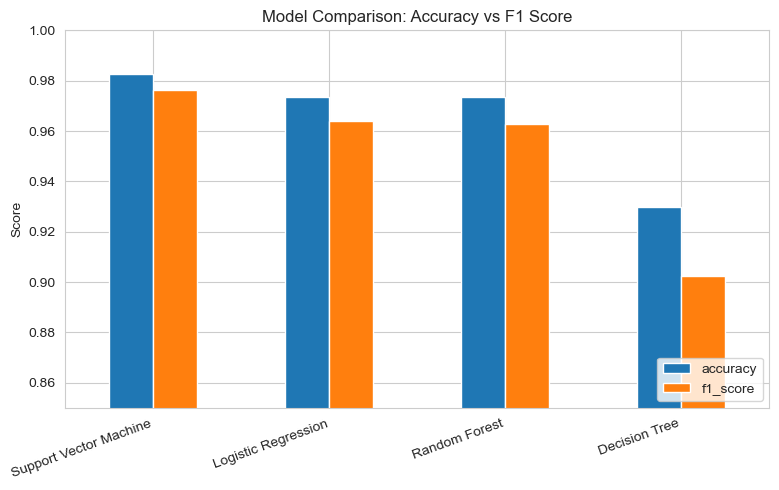

Saved: model comparison chart

Best performing model: Support Vector Machine (Accuracy: 0.9825, F1 Score: 0.9762)


In [34]:
results_df = pd.DataFrame(results).T.sort_values("accuracy", ascending=False)
print(results_df)

plt.figure(figsize=(9, 5))
results_df[['accuracy', 'f1_score']].plot(kind='bar')
plt.title("Model Comparison: Accuracy vs F1 Score")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("plots/09_model_comparison.png", dpi=120)
plt.show()
print("Saved: model comparison chart")

best_model = results_df['accuracy'].idxmax()
print(f"\nBest performing model: {best_model} "
      f"(Accuracy: {results_df.loc[best_model, 'accuracy']:.4f}, "
      f"F1 Score: {results_df.loc[best_model, 'f1_score']:.4f})")





SVM performed best with 98.25% accuracy and the lowest false negative rate — critical in medical diagnosis where missing a malignant tumor is far more dangerous than a false alarm.


**Conclusion**


This project built a machine learning pipeline to classify breast tumors as malignant or benign using the Breast Cancer Wisconsin dataset. Key findings include: cell size and shape irregularity features were the strongest predictors of malignancy, SMOTE effectively addressed class imbalance, and all four models performed well with SVM achieving the highest accuracy of 98.25%. SVM is recommended for this use case due to its high accuracy, strong F1 score, and lowest false negative rate — making it the safest choice for a medical screening application.


